In [31]:
from astropy.io import fits
import numpy as np

#header = fits.getheader(path)
#data = fits.getdata(path)


In [32]:
fitsfile_path = '/user/p5_lecturer/KiDS1000/'
fitsfileName = 'KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits'

def GetHeader(filename):
    return fits.getheader(filename)
    
Header = GetHeader(fitsfile_path + fitsfileName)
#print( Header )

zbins = [0.1,0.3,0.5,0.7,0.9,1.2]

with fits.open(fitsfile_path + fitsfileName) as fname:
    #print( fname.info() )
    #print(fname[1].header)
    Zarray = fname[1].data['Z_B']
    Weight = fname[1].data['weight']
    
    RA     = fname[1].data['RAJ2000']
    DEC    = fname[1].data['DECJ2000']
    e1     = fname[1].data['e1']
    e2     = fname[1].data['e2']
    
    Ngalaxies = len(Zarray)
    print(f'Total Number of galaxies={Ngalaxies}')
    print(f'Zrange ---> {np.min(Zarray)}- {np.max(Zarray)}' )
    print(np.min(Weight), np.max(Weight))
    
A = 777.4
for i in range(len(zbins)-1):
    mask = (Zarray> zbins[i]) & (Zarray<=zbins[i+1])
    Ngal = len(Zarray[mask])
    #print(f'{i} {zbins[i]}-{zbins[i+1]} bin has {Ngal} galaxies ')
    wgt_mask = Weight[mask]
    wgt_mask = np.array(wgt_mask)
    neff = (1/A)*np.sum(wgt_mask)**2/np.sum(wgt_mask**2)
    neff *= (1/3600)
    print(f'{i} {zbins[i]}-{zbins[i+1]} bin has neff={neff:g}  ')




Total Number of galaxies=21262011
Zrange ---> 0.11- 1.2
0.0156 15.5629
0 0.1-0.3 bin has neff=0.616381  
1 0.3-0.5 bin has neff=1.18213  
2 0.5-0.7 bin has neff=1.85412  
3 0.7-0.9 bin has neff=1.25921  
4 0.9-1.2 bin has neff=1.31089  


In [14]:
import treecorr
import matplotlib.pyplot as plt

#treecorr.Catalog?

marker=['o','*', 'P', 'D', '^']
plt.figure(figsize=(10,10))

for i in range(len(zbins)-1):
    mask = (Zarray> zbins[i]) & (Zarray<=zbins[i+1])
    Ngal = len(Zarray[mask])
    #print(f'{i} {zbins[i]}-{zbins[i+1]} bin has {Ngal} galaxies ')
    wgt_mask = Weight[mask]
    cat = treecorr.Catalog(ra=RA[mask],dec=DEC[mask],g1=e1[mask],g2=e2[mask],w=wgt_mask,ra_units='deg',dec_units='deg')
    gg = treecorr.GGCorrelation(min_sep=0.1,max_sep=300,nbins=10,sep_units='arcmin')
    gg.process(cat)
    theta = np.exp(gg.meanlogr)
    xi_plus = gg.xip
    xi_minus = gg.xim
    filename_out = 'xi_plus_minus_auto_zbins_%d.txt'%i
    print(f'Data will be saved at {filename_out} ')
    gg.write(filename_out)  # Write results to a file
    


Data will be saved at xi_plus_minus_auto_zbins_0.txt 
Data will be saved at xi_plus_minus_auto_zbins_1.txt 
Data will be saved at xi_plus_minus_auto_zbins_2.txt 
Data will be saved at xi_plus_minus_auto_zbins_3.txt 
Data will be saved at xi_plus_minus_auto_zbins_4.txt 


<Figure size 1000x1000 with 0 Axes>

In [15]:

for i in range(len(zbins)-1):
    for j in range(i, len(zbins)-1):
            mask1 = (Zarray> zbins[i]) & (Zarray<=zbins[i+1])
            mask2 = (Zarray> zbins[j]) & (Zarray<=zbins[j+1])
            Ngal1 = len(Zarray[mask1])
            Ngal2 = len(Zarray[mask2])
            print(Ngal1, Ngal2)
            wgt_mask1 = Weight[mask1]
            wgt_mask2 = Weight[mask2]
            cat1 = treecorr.Catalog(ra=RA[mask1],dec=DEC[mask1],g1=e1[mask1],g2=e2[mask1],w=wgt_mask1,ra_units='deg',dec_units='deg')
            cat2 = treecorr.Catalog(ra=RA[mask2],dec=DEC[mask2],g1=e1[mask2],g2=e2[mask2],w=wgt_mask2,ra_units='deg',dec_units='deg')
            gg   = treecorr.GGCorrelation(min_sep=0.1,max_sep=300,nbins=10,sep_units='arcmin')
            gg.process(cat1, cat2)
            filename = './Data/xi_plus_minus_%d%d.txt'%(i,j)
            print(f'Data will be stored at {filename} ')
            gg.write(filename)  # Write results to a file



1792136 1792136
Data will be stored at ./Data/xi_plus_minus_00.txt 
1792136 3681319
Data will be stored at ./Data/xi_plus_minus_01.txt 
1792136 6148102
Data will be stored at ./Data/xi_plus_minus_02.txt 
1792136 4544395
Data will be stored at ./Data/xi_plus_minus_03.txt 
1792136 5096059
Data will be stored at ./Data/xi_plus_minus_04.txt 
3681319 3681319
Data will be stored at ./Data/xi_plus_minus_11.txt 
3681319 6148102
Data will be stored at ./Data/xi_plus_minus_12.txt 
3681319 4544395
Data will be stored at ./Data/xi_plus_minus_13.txt 
3681319 5096059
Data will be stored at ./Data/xi_plus_minus_14.txt 
6148102 6148102
Data will be stored at ./Data/xi_plus_minus_22.txt 
6148102 4544395
Data will be stored at ./Data/xi_plus_minus_23.txt 
6148102 5096059
Data will be stored at ./Data/xi_plus_minus_24.txt 
4544395 4544395
Data will be stored at ./Data/xi_plus_minus_33.txt 
4544395 5096059
Data will be stored at ./Data/xi_plus_minus_34.txt 
5096059 5096059
Data will be stored at ./Data/xi

In [34]:
import treecorr

for i in range(len(zbins)-1):
    for j in range(i, len(zbins)-1):
            mask1 = (Zarray> zbins[i]) & (Zarray<=zbins[i+1])
            mask2 = (Zarray> zbins[j]) & (Zarray<=zbins[j+1])
            Ngal1 = len(Zarray[mask1])
            Ngal2 = len(Zarray[mask2])
            print(Ngal1, Ngal2)
            wgt_mask1 = Weight[mask1]
            wgt_mask2 = Weight[mask2]
            c1 = np.sum(wgt_mask1*e1[mask1])/np.sum(wgt_mask1)
            c2 = np.sum(wgt_mask2*e2[mask2])/np.sum(wgt_mask2)
            e1_new_1 = e1[mask1] - np.sum(wgt_mask1*e1[mask1])/np.sum(wgt_mask1)
            e2_new_1 = e2[mask1] - np.sum(wgt_mask1*e2[mask1])/np.sum(wgt_mask1)
            e1_new_2 = e1[mask2] - np.sum(wgt_mask2*e1[mask2])/np.sum(wgt_mask2)
            e2_new_2 = e2[mask2] - np.sum(wgt_mask2*e2[mask2])/np.sum(wgt_mask2)
            cat1 = treecorr.Catalog(ra=RA[mask1],dec=DEC[mask1],g1=e1_new_1, g2=e2_new_1, w=wgt_mask1,ra_units='deg',dec_units='deg')
            cat2 = treecorr.Catalog(ra=RA[mask2],dec=DEC[mask2],g1=e1_new_2, g2=e2_new_2, w=wgt_mask2,ra_units='deg',dec_units='deg')
            gg   = treecorr.GGCorrelation(min_sep=0.1,max_sep=300,nbins=10,sep_units='arcmin')
            gg.process(cat1, cat2)
            filename = './Data/xi_plus_minus_%d%d_shear_correction.txt'%(i,j)
            print(f'Data will be stored at {filename} ')
            gg.write(filename)  # Write results to a file-------


    

1792136 1792136
Data will be stored at ./Data/xi_plus_minus_00_shear_correction.txt 
1792136 3681319
Data will be stored at ./Data/xi_plus_minus_01_shear_correction.txt 
1792136 6148102
Data will be stored at ./Data/xi_plus_minus_02_shear_correction.txt 
1792136 4544395
Data will be stored at ./Data/xi_plus_minus_03_shear_correction.txt 
1792136 5096059
Data will be stored at ./Data/xi_plus_minus_04_shear_correction.txt 
3681319 3681319
Data will be stored at ./Data/xi_plus_minus_11_shear_correction.txt 
3681319 6148102
Data will be stored at ./Data/xi_plus_minus_12_shear_correction.txt 
3681319 4544395
Data will be stored at ./Data/xi_plus_minus_13_shear_correction.txt 
3681319 5096059
Data will be stored at ./Data/xi_plus_minus_14_shear_correction.txt 
6148102 6148102
Data will be stored at ./Data/xi_plus_minus_22_shear_correction.txt 
6148102 4544395
Data will be stored at ./Data/xi_plus_minus_23_shear_correction.txt 
6148102 5096059
Data will be stored at ./Data/xi_plus_minus_24_sh

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

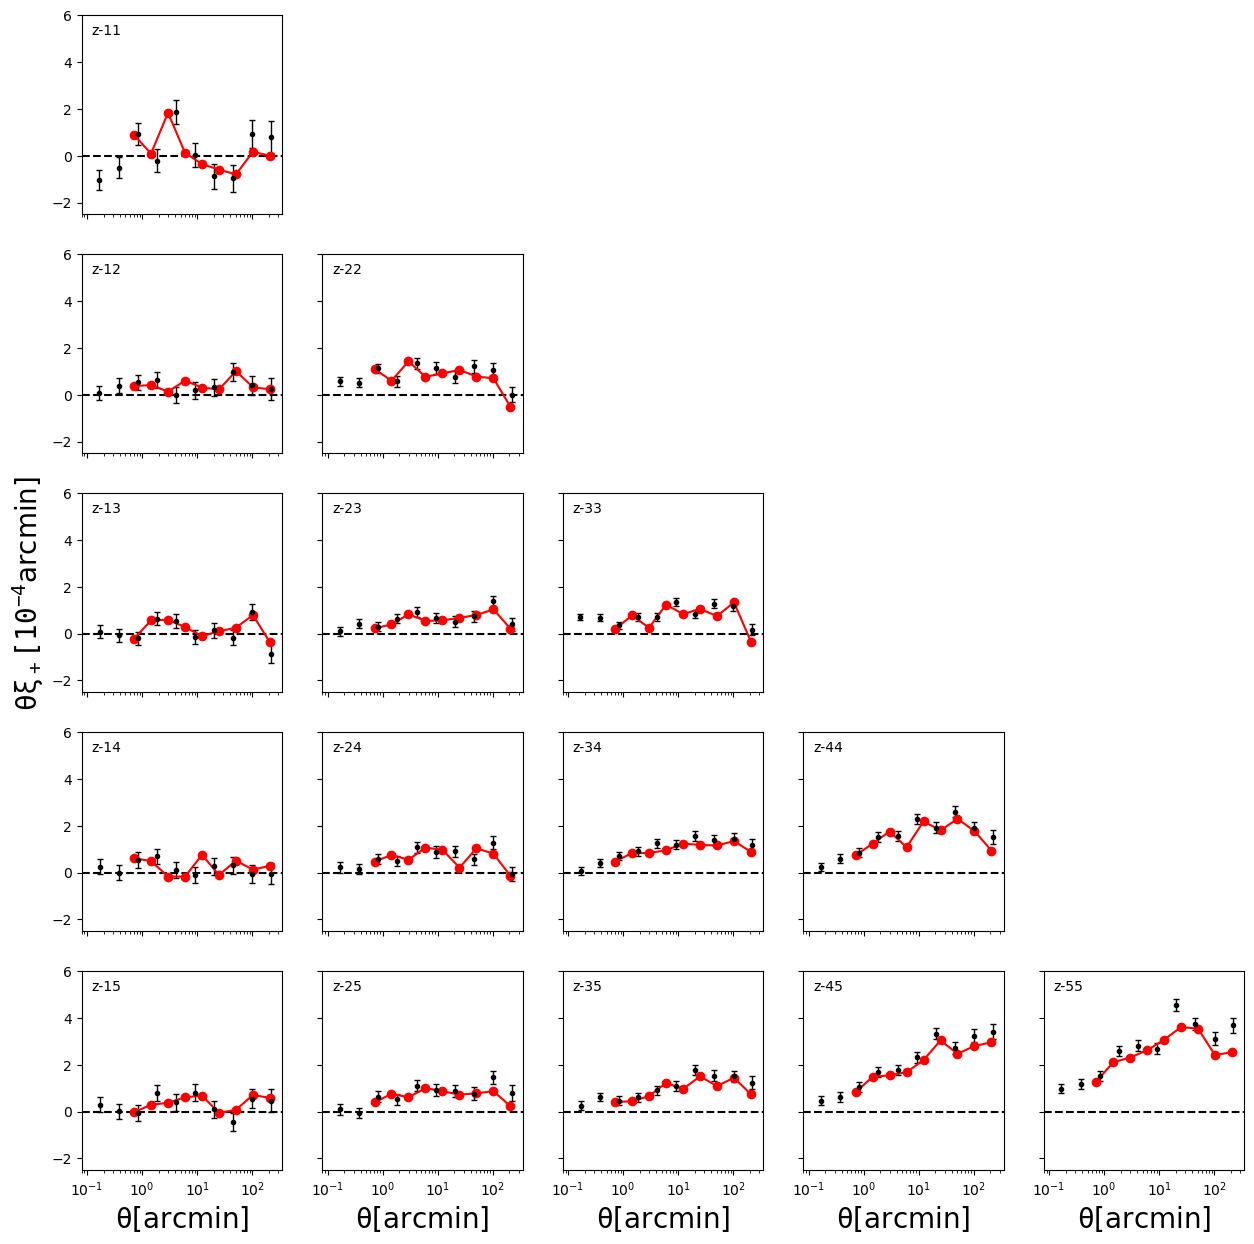

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def GetHeader(filename):
    return fits.getheader(filename)

nbin = 5
arun_datafile = '/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits'
Header_arun = GetHeader( arun_datafile )
print(Header_arun)
ArunData = fits.open(arun_datafile)
CovMat   = ArunData['COVMAT'].data
xip_arun = ArunData['xiP'].data
xim_arun = ArunData['xiM'].data
print(ArunData['xiP'].columns)
print(ArunData['xiM'].columns)
#print(xip_arun)
#print( CovMat )
print(type(xim_arun))


fig, ax = plt.subplots(nbin, nbin,
                       figsize=(15,15),
                       sharex=True,
                       sharey=True)

for i in range(nbin):
    for j in range(nbin):

        #-------------Hide the upper triangle------------
        if j > i:
            ax[i,j].axis('off')
            continue
        
        #filename = f'./Data/xi_plus_minus_{j}{i}.txt'
        filename = f'./Data/xi_plus_minus_{j}{i}_shear_correction.txt'

        data = np.loadtxt(filename)
        theta = data[:,1]
        xip   = data[:,3]
        xim   = data[:,4]
        sigma_p = data[:,7]
        sigma_m = data[:,8]
        ax[i, j].errorbar(theta,theta*xip*1e+4, yerr=sigma_p*theta*1e+4,fmt='o',  ms=3, color='k', capsize=2, elinewidth=1,linestyle='none')
        #ax[i, j].errorbar(theta,theta*xim*1e+4, yerr=sigma_m*theta*1e+4,fmt='o',  ms=3, color='k', capsize=2, elinewidth=1,linestyle='none')
        ax[i,j].set_ylim([-2.5,6.0])
        ax[i,j].set_xscale('log')
        ax[i,j].axhline(0,color='k', ls='--')
        ax[i, j].text(0.05, 0.90,f'z-{j+1}{i+1}',transform=ax[i, j].transAxes,fontsize=10)
        #--------------------------------------------------------------------------------------
        #--------------compare with paper------------------------------------------------------
        #mask_paper = (xim_arun['BIN1'] == j+1) & (xim_arun['BIN2'] == i+1)
        #theta_paper = xim_arun['ANG'][mask_paper]
        #xim_paper   = xim_arun['VALUE'][mask_paper]
        #ax[i, j].scatter(theta_paper, theta_paper*xim_paper*1e+4, marker='o', s=5, color='red')
        #ax[i, j].plot(theta_paper, theta_paper*xim_paper*1e+4, marker='o', color='red')

        mask_paper = (xip_arun['BIN1'] == j+1) & (xip_arun['BIN2'] == i+1)
        theta_paper = xip_arun['ANG'][mask_paper]
        xip_paper   = xip_arun['VALUE'][mask_paper]
        #ax[i, j].scatter(theta_paper, theta_paper*xip_paper*1e+4, marker='o', s=5, color='red')
        ax[i, j].plot(theta_paper, theta_paper*xip_paper*1e+4, marker='o', color='red')

ax[2,0].set_ylabel(r'$\mathtt{\theta \xi_+[10^{-4}}$arcmin]', fontsize=20)

for i in range(5):
    for j in range(i+1):
        ax[i,j].set_xlim(0.08,350)
        
for i in range(5):
    ax[4,i].set_xlabel(r'$\mathtt{\theta}$[arcmin]', fontsize=20)

#plt.savefig('xi_plus_all_zbins_auto_cross_terms.png', bbox_inches='tight', dpi=300)
#plt.savefig('xi_minus_all_zbins_auto_cross_terms.png', bbox_inches='tight', dpi=300)

#plt.savefig('xi_plus_all_zbins_auto_cross_terms_shear_correction.png', bbox_inches='tight', dpi=300)

plt.show()



SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

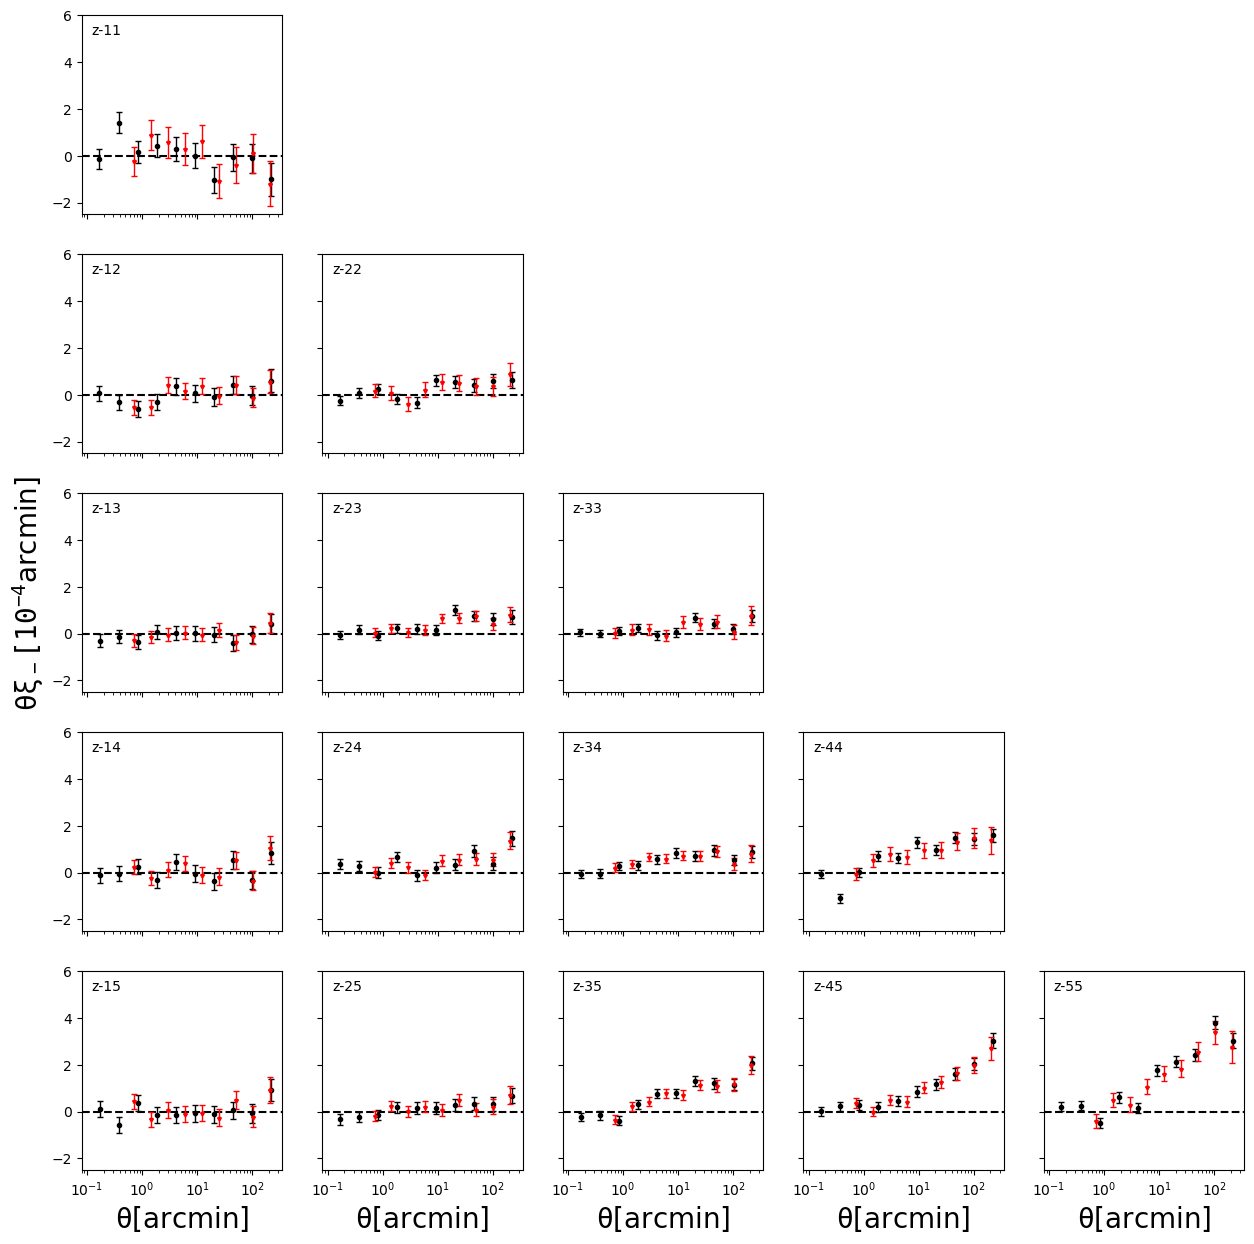

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def GetHeader(filename):
    return fits.getheader(filename)

nbin = 5
arun_datafile = '/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits'
Header_arun = GetHeader( arun_datafile )
print(Header_arun)
ArunData = fits.open(arun_datafile)
CovMat   = ArunData['COVMAT'].data
xip_arun = ArunData['xiP'].data
xim_arun = ArunData['xiM'].data
print(ArunData['xiP'].columns)
print(ArunData['xiM'].columns)
#print(xip_arun)
print( CovMat.shape )
sigma_xip_paper = np.sqrt(np.diag(CovMat[:135, :135]))
sigma_xim_paper = np.sqrt(np.diag(CovMat[135:, 135:]))
print(sigma_xip_paper.shape, sigma_xim_paper.shape)

mvals = [-0.009, -0.011, -0.015, 0.002, 0.007]

fig, ax = plt.subplots(nbin, nbin,
                       figsize=(15,15),
                       sharex=True,
                       sharey=True)

for i in range(nbin):
    for j in range(nbin):

        #-------------Hide the upper triangle------------
        if j > i:
            ax[i,j].axis('off')
            continue
        
        #filename = f'./Data/xi_plus_minus_{j}{i}.txt'
        filename = f'./Data/xi_plus_minus_{j}{i}_shear_correction.txt'

        data = np.loadtxt(filename)
        theta = data[:,1]
        xip   = data[:,3]
        xim   = data[:,4]
        sigma_p = data[:,7]
        sigma_m = data[:,8]
        #ax[i, j].errorbar(theta,theta*(xip/( (1 + mvals[i])*(1 + mvals[j]) ) )*1e+4, yerr=(theta*1e+4)*sigma_p/( (1 + mvals[i])*(1 + mvals[j]) ),fmt='o',  ms=3, color='k', capsize=2, elinewidth=1,linestyle='none')
        ax[i, j].errorbar(theta, theta*(xim/( (1 + mvals[i])*(1 + mvals[j]) ) )*1e+4, yerr=(theta*1e+4)*sigma_m/( (1 + mvals[i])*(1 + mvals[j]) ),fmt='o',  ms=3, color='k', capsize=2, elinewidth=1,linestyle='none')
        ax[i,j].set_ylim([-2.5,6.0])
        ax[i,j].set_xscale('log')
        ax[i,j].axhline(0,color='k', ls='--')
        ax[i, j].text(0.05, 0.90,f'z-{j+1}{i+1}',transform=ax[i, j].transAxes,fontsize=10)
        #--------------------------------------------------------------------------------------
        #--------------compare with paper------------------------------------------------------
        mask_paper = (xim_arun['BIN1'] == j+1) & (xim_arun['BIN2'] == i+1)
        theta_paper = xim_arun['ANG'][mask_paper]
        xim_paper   = xim_arun['VALUE'][mask_paper]
        sigma_xim_mask = sigma_xim_paper[mask_paper]
        #ax[i, j].scatter(theta_paper, theta_paper*xim_paper*1e+4, marker='o', s=5, color='red')
        #ax[i, j].plot(theta_paper, theta_paper*xim_paper*1e+4, marketheta_paper))
        ax[i,j].errorbar(theta_paper, theta_paper*xim_paper*1e+4, yerr = (theta_paper*1e+4)*sigma_xim_mask, fmt='*',  ms=3, color='red', capsize=2, elinewidth=1,linestyle='none')
        ax[i,j].set_ylim([-2.5,6.0])
        
        #mask_paper = (xip_arun['BIN1'] == j+1) & (xip_arun['BIN2'] == i+1)
        #theta_paper = xip_arun['ANG'][mask_paper]
        #xip_paper   = xip_arun['VALUE'][mask_paper]
        #sigma_xip_mask = sigma_xip_paper[mask_paper]
        #ax[i, j].scatter(theta_paper, theta_paper*xip_paper*1e+4, marker='o', s=5, color='red')
        #ax[i, j].plot(theta_paper, theta_paper*xip_paper*1e+4, marker='o', color='red')
        #ax[i, j].plot(theta_paper, theta_paper*xip_paper/( (1 + mvals[i])*(1 + mvals[j]) ) *1e+4, marker='o', color='red')
        #ax[i,j].errorbar(theta_paper, theta_paper*xip_paper*1e+4, yerr = (theta_paper*1e+4)*sigma_xip_mask, fmt='*',  ms=3, color='red', capsize=2, elinewidth=1, linestyle='none')

ax[2,0].set_ylabel(r'$\mathtt{\theta \xi_-[10^{-4}}$arcmin]', fontsize=20)

for i in range(5):
    for j in range(i+1):
        ax[i,j].set_xlim(0.08,350)
        
for i in range(5):
    ax[4,i].set_xlabel(r'$\mathtt{\theta}$[arcmin]', fontsize=20)

#plt.savefig('xi_plus_by_shearbias_all_zbins_auto_cross_terms.png', bbox_inches='tight', dpi=300)
#plt.savefig('xi_minus_by_shearbias_all_zbins_auto_cross_terms.png', bbox_inches='tight', dpi=300)

#plt.savefig('xi_plus_all_zbins_auto_cross_terms_shear_correction.png', bbox_inches='tight', dpi=300)
plt.savefig('xi_minus_all_zbins_auto_cross_terms_shear_correction.png', bbox_inches='tight', dpi=300)

plt.show()


xi_plus_minus_zbins_0.txt
xi_plus_minus_zbins_1.txt
xi_plus_minus_zbins_2.txt
xi_plus_minus_zbins_3.txt
xi_plus_minus_zbins_4.txt


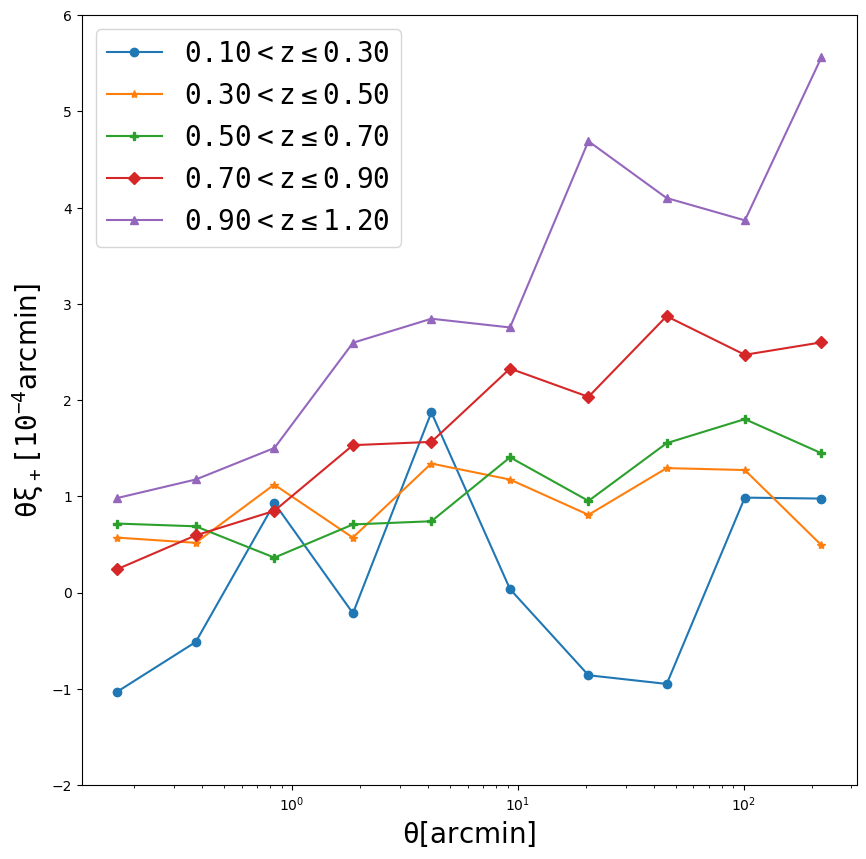

In [56]:
plt.figure(figsize=(10,10))


for i in range(len(zbins)-1):
    filename = 'xi_plus_minus_zbins_%d.txt'%i
    print(filename)
    data = np.loadtxt(filename)
    thetaVals = data[:,1]
    xi_plus = data[:,3]
    xi_minus = data[:,4]
    plt.plot(thetaVals, thetaVals*xi_plus*1e+4,marker=marker[i], label=r'$\mathtt{%.2f < z \leq %.2f}$'%(zbins[i], zbins[i+1]) )
    #plt.plot(thetaVals, thetaVals*xi_minus*1e+4, marker=marker[i], label=r'$\mathtt{%.2f < z \leq %.2f}$'%(zbins[i], zbins[i+1]) )

plt.xscale('log')
#plt.yscale('log')
plt.ylim([-2,+6])
plt.xlabel(r'$\mathtt{\theta}$[arcmin]', fontsize=20)
plt.ylabel(r'$\mathtt{\theta \xi_+[10^{-4}}$arcmin]', fontsize=20)

plt.legend(fontsize=20)
#plt.savefig('xi_minus_all_zbins.png', bbox_inches='tight', dpi=300)

plt.savefig('xi_plus_all_zbins.png', bbox_inches='tight', dpi=300)

plt.show()


Yes,/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO1_Nz.asc exists 

Yes,/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO2_Nz.asc exists 

Yes,/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO3_Nz.asc exists 

Yes,/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO4_Nz.asc exists 

Yes,/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO5_Nz.asc exists 

0.6985957607886555 7.75323815566109e-15
0.6390166202296567 7.0943142853330254e-15
0.5417569647396124 6.01432017252948e-15
0.5203200583742212 5.77672404269286e-15
0.43741797063614707 1.307719849439647e-08


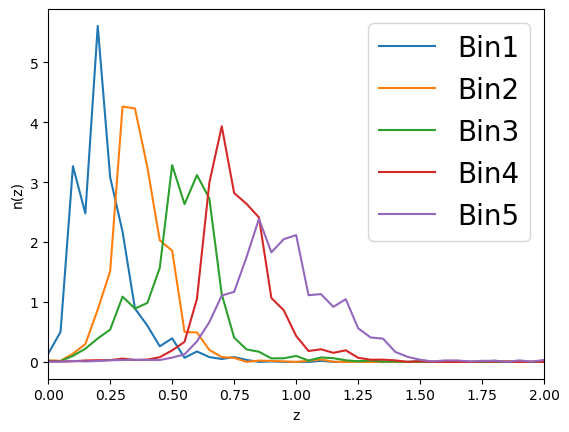

In [56]:
import os, sys
import time
import numpy as np


flist = []
for i in range(1,6,1):
    TOM_file = f'/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO{i:01d}_Nz.asc'
    if os.path.exists(TOM_file):
        print(f'Yes,{TOM_file} exists \n')
    else:
        print(f'No, {TOM_file} does not exist \n')
    flist.append(TOM_file)

#print(flist)

import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

def Hist(zarr, Nz, bins):
    Ncount, Bin_edges = np.histogram(zarr, bins=bins)
    Midvals = 0.5*(Bin_edges[1:] + Bin_edges[:-1])
    Binwidth = Bin_edges[1] - Bin_edges[0]
    Nhist = Ncount/(Binwidth*len(zarr))
    MeanNz, Bin_edges, _ = binned_statistic(
        zarr, Nz, statistic='mean', bins=bins)
    return MeanNz, Nhist, Midvals


from scipy.interpolate import interp1d
from scipy.integrate import quad

zbins = [0.1, 0.3, 0.5, 0.7, 0.9, 1.2]

for i,filename in enumerate(flist):
    #print(filename)
    Data = np.genfromtxt(filename)
    zarray = Data[:,0]
    NumDensity = Data[:,1]
    binwidth= np.diff(zarray)[0]

    InterpFunc = interp1d(zarray, NumDensity/binwidth, kind='cubic',bounds_error=False)
    #bins = np.linspace(np.min(zarray)-1e-6, np.max(zarray)+1e-6, nbin)
    #MeanNz, Nhist, Midvals = Hist(zarray, NumDensity, bins)
    plt.plot(zarray, NumDensity/binwidth, label=f'Bin{i+1}')
    #print(len(zbins), len(NumDensity) )
    #print(np.sum(NumDensity))
    Result, error = quad( InterpFunc, zbins[i], zbins[i+1] )
    print(Result, error)
    
plt.xlabel('z')
plt.ylabel('n(z)')
plt.xlim([0,2])
plt.legend(fontsize=20)
plt.savefig('dist_galaxies_5_tomographicbins.png', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
#------------------calculate area------------------------
